In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Customer Purchasing Behaviors.csv')
df.head()

,user_id,age,annual_income,purchase_amount,loyalty_score,region,purchase_frequency
0,1,25,45000,200,4.5,North,12
1,2,34,55000,350,7.0,South,18
2,3,45,65000,500,8.0,West,22
3,4,22,30000,150,3.0,East,10
4,5,29,47000,220,4.8,North,13


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   user_id             238 non-null    int64  
 1   age                 238 non-null    int64  
 2   annual_income       238 non-null    int64  
 3   purchase_amount     238 non-null    int64  
 4   loyalty_score       238 non-null    float64
 5   region              238 non-null    str    
 6   purchase_frequency  238 non-null    int64  
dtypes: float64(1), int64(5), str(1)
memory usage: 14.2 KB


In [4]:
df.describe()

,user_id,age,annual_income,purchase_amount,loyalty_score,purchase_frequency
count,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000
mean,119.500000,38.676471,57407.563025,425.630252,6.794118,19.798319
std,68.848868,9.351118,11403.875717,140.052062,1.899047,4.562884
min,1.000000,22.000000,30000.000000,150.000000,3.000000,10.000000
25%,60.250000,31.000000,50000.000000,320.000000,5.500000,17.000000
50%,119.500000,39.000000,59000.000000,440.000000,7.000000,20.000000
75%,178.750000,46.750000,66750.000000,527.500000,8.275000,23.000000
max,238.000000,55.000000,75000.000000,640.000000,9.500000,28.000000


In [5]:
df.shape

(238, 7)

In [6]:
df.duplicated().sum()

np.int64(0)

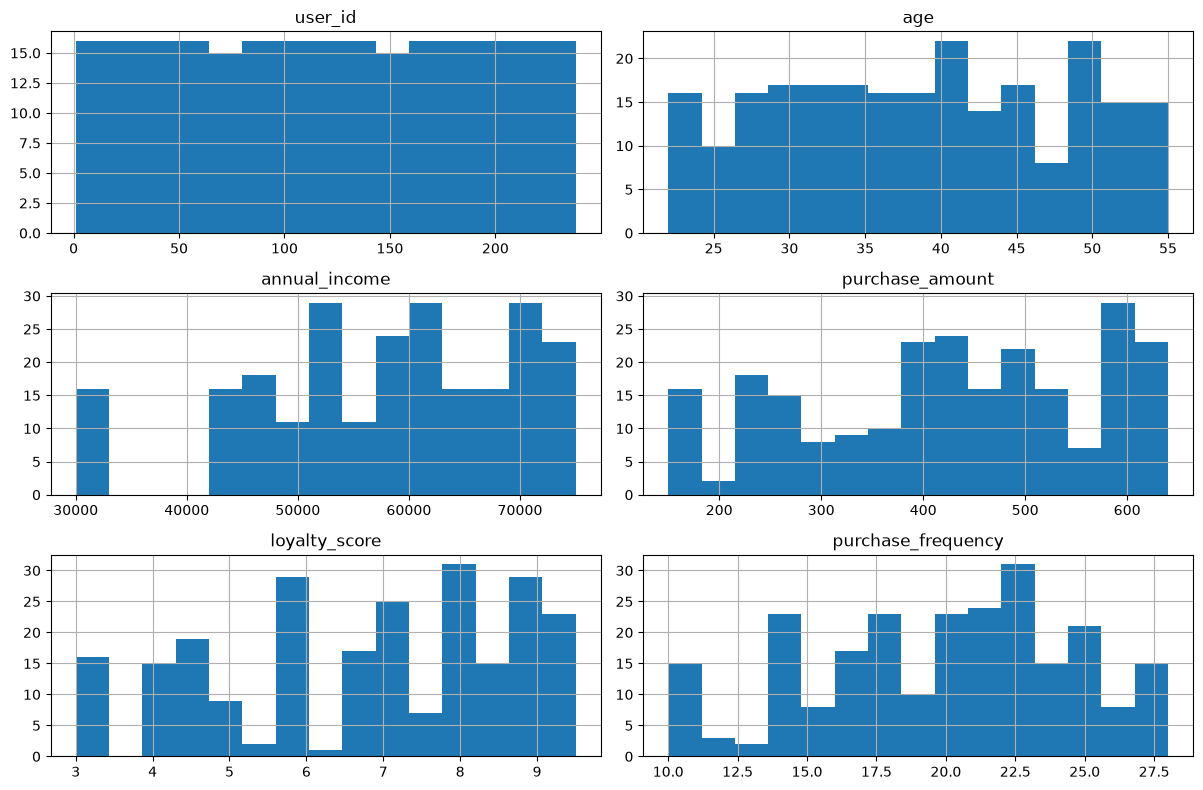

In [7]:
df.hist(figsize=(12, 8), bins=15)
plt.tight_layout()
plt.show()

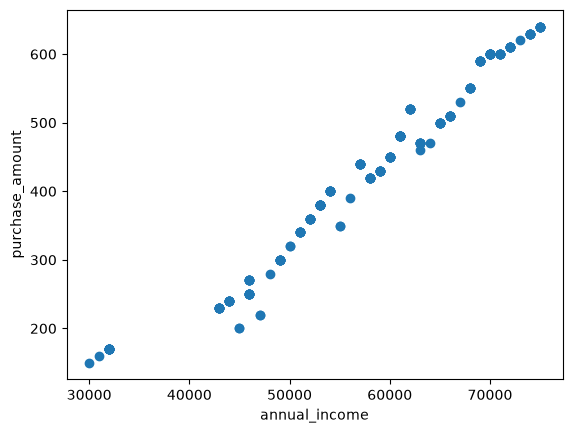

In [8]:
plt.scatter(df['annual_income'], df['purchase_amount'])
plt.xlabel('annual_income')
plt.ylabel('purchase_amount')
plt.show()

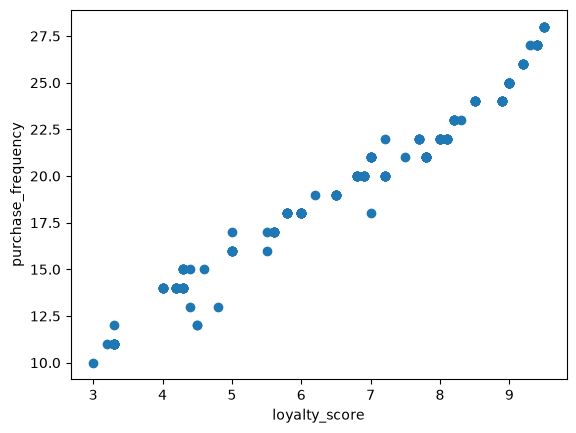

In [9]:
plt.scatter(df['loyalty_score'], df['purchase_frequency'])
plt.xlabel('loyalty_score')
plt.ylabel('purchase_frequency')
plt.show()

In [10]:
features = df.drop(columns=['user_id', 'region'])
features.head()

,age,annual_income,purchase_amount,loyalty_score,purchase_frequency
0,25,45000,200,4.5,12
1,34,55000,350,7.0,18
2,45,65000,500,8.0,22
3,22,30000,150,3.0,10
4,29,47000,220,4.8,13


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [12]:
pd.DataFrame(scaled_features, columns=features.columns).describe()

,age,annual_income,purchase_amount,loyalty_score,purchase_frequency
count,2.380000e+02,2.380000e+02,2.380000e+02,2.380000e+02,2.380000e+02
mean,-2.910837e-16,2.201787e-16,7.463684e-17,4.478211e-17,-1.231508e-16
std,1.002107e+00,1.002107e+00,1.002107e+00,1.002107e+00,1.002107e+00
min,-1.787125e+00,-2.408420e+00,-1.972203e+00,-2.002117e+00,-2.151922e+00
25%,-8.226448e-01,-6.509343e-01,-7.558108e-01,-6.828926e-01,-6.145711e-01
50%,3.467085e-02,1.399343e-01,1.028191e-01,1.086420e-01,4.429341e-02
75%,8.651954e-01,8.209600e-01,7.289035e-01,7.814464e-01,7.031579e-01
max,1.749302e+00,1.545923e+00,1.533869e+00,1.427866e+00,1.801265e+00


In [13]:
from sklearn.cluster import KMeans

inertia_values = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia_values.append(kmeans.inertia_)

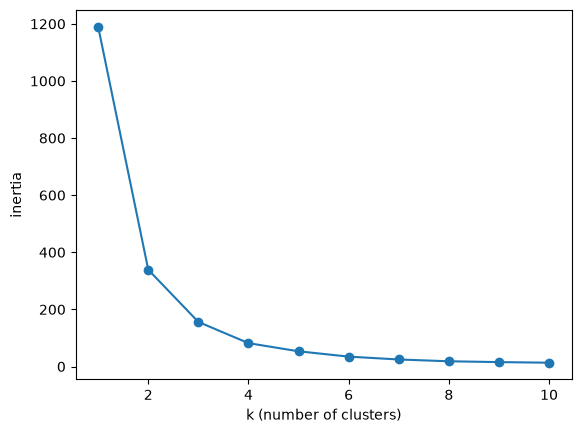

In [14]:
plt.plot(k_range, inertia_values, marker='o')
plt.xlabel('k (number of clusters)')
plt.ylabel('inertia')
plt.show()

In [15]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
k_range_sil = range(2, 11)

for k in k_range_sil:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(scaled_features)
    score = silhouette_score(scaled_features, labels)
    silhouette_scores.append(score)

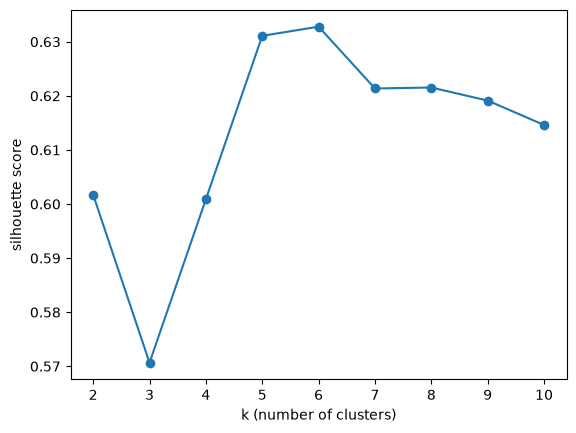

In [16]:
plt.plot(k_range_sil, silhouette_scores, marker='o')
plt.xlabel('k (number of clusters)')
plt.ylabel('silhouette score')
plt.show()

In [17]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(scaled_features)

In [18]:
df['cluster'] = cluster_labels
df.head()

,user_id,age,annual_income,purchase_amount,loyalty_score,region,purchase_frequency,cluster
0,1,25,45000,200,4.5,North,12,2
1,2,34,55000,350,7.0,South,18,1
2,3,45,65000,500,8.0,West,22,3
3,4,22,30000,150,3.0,East,10,2
4,5,29,47000,220,4.8,North,13,2


In [19]:
df['cluster'].value_counts()

cluster
3    77
0    60
2    51
1    50
Name: count, dtype: int64

In [20]:
df.groupby('cluster')[['age', 'annual_income', 'purchase_amount', 'loyalty_score', 'purchase_frequency']].mean()

,age,annual_income,purchase_amount,loyalty_score,purchase_frequency
cluster,,,,,
0,51.066667,71066.666667,601.500000,9.053333,25.466667
1,32.560000,52100.000000,358.200000,5.846000,17.700000
2,26.274510,40803.921569,219.411765,3.949020,13.098039
3,41.207792,61207.792208,468.961039,7.533766,21.181818


In [21]:
pd.crosstab(df['cluster'], df['region'])

region,East,North,South,West
cluster,,,,
0,0,8,9,43
1,0,22,18,10
2,3,31,14,3
3,3,17,36,21


In [22]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_features)

In [23]:
pca.explained_variance_ratio_

array([0.98796992, 0.00511046])

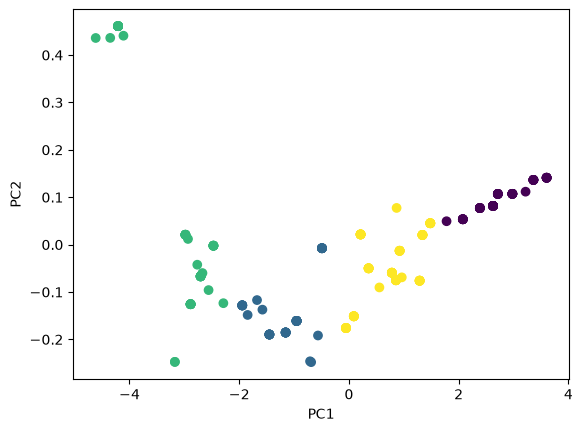

In [24]:
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=cluster_labels, cmap='viridis')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

In [25]:
import joblib

joblib.dump(kmeans_final, 'kmeans_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [26]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(scaled_features, method='ward')

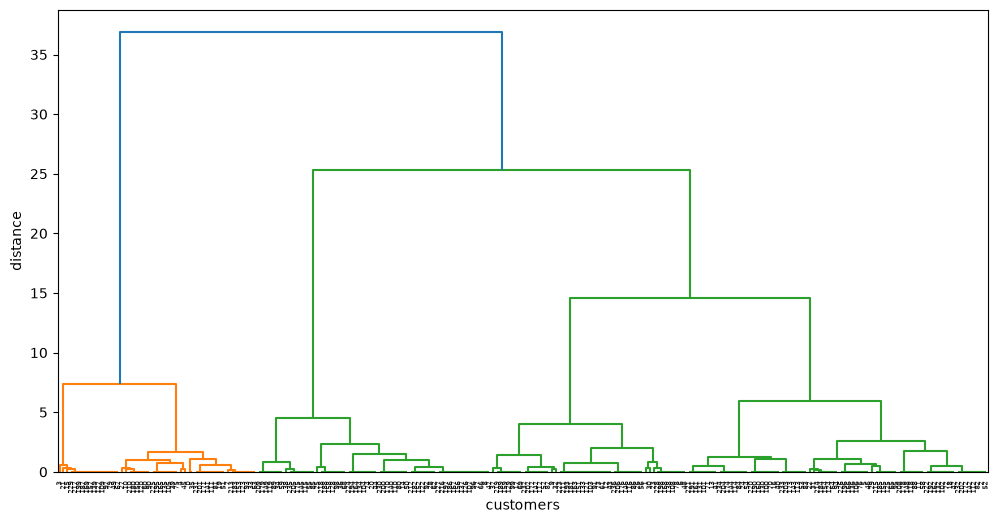

In [27]:
plt.figure(figsize=(12, 6))
dendrogram(linked)
plt.xlabel('customers')
plt.ylabel('distance')
plt.show()

In [28]:
from scipy.cluster.hierarchy import fcluster

hierarchical_labels = fcluster(linked, t=4, criterion='maxclust')
df['cluster_hierarchical'] = hierarchical_labels

In [29]:
df['cluster_hierarchical'].value_counts()

cluster_hierarchical
4    77
2    60
1    51
3    50
Name: count, dtype: int64

In [30]:
pd.crosstab(df['cluster'], df['cluster_hierarchical'])

cluster_hierarchical,1,2,3,4
cluster,,,,
0,0,60,0,0
1,0,0,50,0
2,51,0,0,0
3,0,0,0,77


In [31]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(scaled_features)
distances, indices = neighbors_fit.kneighbors(scaled_features)
distances = np.sort(distances[:, -1])

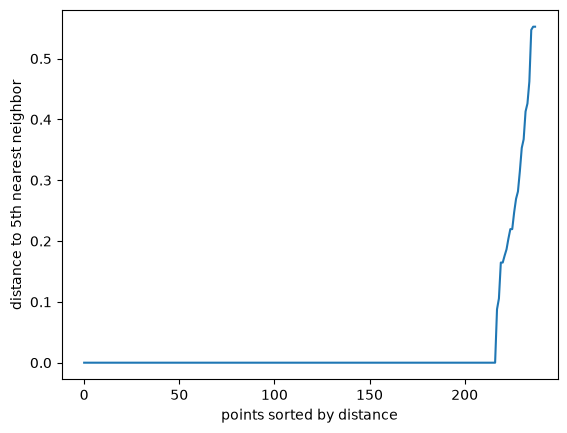

In [32]:
plt.plot(distances)
plt.xlabel('points sorted by distance')
plt.ylabel('distance to 5th nearest neighbor')
plt.show()

In [33]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.18, min_samples=10)
dbscan_labels = dbscan.fit_predict(scaled_features)
df['cluster_dbscan'] = dbscan_labels

In [34]:
df['cluster_dbscan'].value_counts()

cluster_dbscan
-1    141
 2     21
 0     16
 1     16
 4     16
 3     14
 5     14
Name: count, dtype: int64

In [35]:
dbscan2 = DBSCAN(eps=0.3, min_samples=10)
dbscan_labels2 = dbscan2.fit_predict(scaled_features)
df['cluster_dbscan2'] = dbscan_labels2
df['cluster_dbscan2'].value_counts()

cluster_dbscan2
-1    63
 3    52
 2    31
 1    22
 4    22
 0    16
 6    16
 5    16
Name: count, dtype: int64

In [36]:
dbscan3 = DBSCAN(eps=0.45, min_samples=10)
dbscan_labels3 = dbscan3.fit_predict(scaled_features)
df['cluster_dbscan3'] = dbscan_labels3
df['cluster_dbscan3'].value_counts()

cluster_dbscan3
 0    130
 2     82
 1     16
-1     10
Name: count, dtype: int64

In [37]:
joblib.dump(dbscan2, 'dbscan_model.pkl')
joblib.dump(dbscan3, 'dbscan_model_loose.pkl')

['dbscan_model_loose.pkl']